# Olink Baseline Cross-sectional Comparison of HC1|CONV|NONC|ERA

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(purrr)
quiet_library(furrr)
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
quiet_library(forcats)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(ggplot2)
quiet_library(ggrepel)
quiet_library(RColorBrewer)

In [3]:
plan(multisession, workers = 3)

In [4]:
if(!dir.exists("/home/workspace/temp/output")) {
    dir.create("/home/workspace/temp/output")
}

outFiles <- list()

In [5]:
# function to remove OlinkIDs with missing NPX values in 2 or more groups - will cause model to error out

removeMissingOID <- function(df) {

    # identify OlinkIDs
    a <- df %>%
        group_by(OlinkID, Status) %>%
        count() %>%
        pivot_wider(names_from = Status, 
                    values_from = n) %>%
        ungroup() %>%
        mutate(across(where(is.integer), is.na),
               sumNA = rowSums(pick(where(is.logical)))) %>%
        filter(sumNA > 1)

    print(paste('Number of missing olink IDs =', nrow(a)))

    # remove OlinkIDs
    b <- df %>%
        filter(!OlinkID %in% a$OlinkID)

}

In [6]:
# function to calculate q values on proteins associated with specific covariates

covarQ <- function(df, cov, Q){
    
    a <- df %>%
        filter(variable == paste0(cov))

    set.seed(123)
    b <- qvalue(a$`Pr(>|t|)`)

    c <- a %>%
        mutate(qval = b$qvalues, 
               pcat = ifelse(Estimate > 0 & qval <= Q, 
                             'Up', 
                             ifelse(Estimate < 0 & qval <= Q, 
                                    'Down', 
                                    'NS')))

}

## Read in baseline ARI olink data

In [7]:
# from IDE for ALTRA Olink Data for Aim 1: CON | ARI (No Subject Metadata) 2024-12-18

a1_uuid <- 'cc6d77a7-7299-42a8-a0dc-b7edaf056c67' # vadof-pofus-pigip/2024-12-18_Olink_altraHCvARI_noMeta.csv

In [8]:
a1_file <- cacheFiles(list(a1_uuid))

a1 <- read.csv(a1_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a1)

[1] "downloading fileID cc6d77a7-7299-42a8-a0dc-b7edaf056c67"


[1] 108283

## Read in baseline ERA olink data

In [9]:
# from IDE for ALTRA Olink Data for Aim 2 (CON | ERA) 2024-10-22

a2_uuid <- '78d58a68-f030-4ef5-b60a-4aedb2a5ad85' # tafug-kasir-kasap/2024-10-22_Olink_altraHCvERA.csv

In [10]:
a2_file <- cacheFiles(list(a2_uuid))

a2 <- read.csv(a2_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a2)

[1] "downloading fileID 78d58a68-f030-4ef5-b60a-4aedb2a5ad85"


[1] 85294

In [11]:
terms <- c('sample', 'subject', 'cohort', 'age', 'time', 'bmi', 'BMI', 'days', 'Status', 'aim')

keep_a2 <- a2 %>%
    select(SampleID,
           sample.sampleKitGuid,
           !contains(terms))

nrow(keep_a2)

[1] 85294

## Read in Aim 1 HC1|ARI differential proteins

In [12]:
# from IDE for ALTRA Olink Results Aim 1: CON | ARI 2024-10-22

dap_uuid <- '2455b335-7f8f-4839-9145-752cabfe319c' # zahin-totok-popin/2024-10-22_Risk_lm_riskVariable.csv

In [13]:
dap_file <- cacheFiles(list(dap_uuid))

dap <- read.csv(dap_file, 
                header = T, 
                stringsAsFactors = F)

nrow(dap)

[1] "downloading fileID 2455b335-7f8f-4839-9145-752cabfe319c"


[1] 1327

In [14]:
dap2 <- dap %>%
    select(OlinkID, 
           qval) %>%
    rename(aim1_qval = qval)

nrow(dap2)

[1] 1327

## Read in metadata

In [15]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [16]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

In [17]:
conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
          'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
          'SD1003', 'SD1007')

outSubj <- c('CU1002')

outCols <- c('Status_Long')

In [18]:
meta2 <- meta %>%
    select(-any_of(outCols)) %>%
    filter(!subject.subjectGuid %in% outSubj, 
           Status_Xsec %in% c('ALTRA_healthy', 'at_risk') | 
           Status_Xsec == 'early_RA' & !subject.subjectGuid %in% conv) %>%
    mutate(Status = ifelse(Status_Xsec == 'ALTRA_healthy' | Status_Xsec == 'early_RA', 
                           Status_Xsec, 
                           ifelse(Status_Xsec == 'at_risk' & subject.subjectGuid %in% conv, 
                                  'converter', 
                                  'non_converter')))

In [19]:
table(meta2$Status, meta2$Status_Xsec)

               
                ALTRA_healthy at_risk early_RA
  ALTRA_healthy            38       0        0
  converter                 0      14        0
  early_RA                  0       0       11
  non_converter             0      30        0

## Merge olink data and metadata

In [20]:
risk <- a1 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid')

nrow(risk)

[1] 106961

In [21]:
era <- keep_a2 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid') %>%
    filter(Status == 'early_RA')

nrow(era)

[1] 14727

In [22]:
all <- risk %>%
    bind_rows(era)

nrow(all)

New names:
• `record_id...112` -> `record_id...146`
• `record_id...120` -> `record_id...154`
• `record_id...114` -> `record_id...158`
• `record_id...123` -> `record_id...159`
New names:
• `record_id...112` -> `record_id...146`
• `record_id...120` -> `record_id...154`
• `record_id...114` -> `record_id...158`
• `record_id...123` -> `record_id...159`


[1] 121688

## Model protein expression | Reference = Converters (CONV)
Linear model <br>
Covariates = age + sex <br>
Note: Missing height, weight on an ERA participant, which causes an error in the model if BMI is included

In [23]:
allv2 <- removeMissingOID(all)

nrow(allv2)

[1] "Number of missing olink IDs = 26"


[1] 121402

In [24]:
# update reference point

allv3 <- allv2 %>%
    mutate(Status = factor(allv2$Status, levels = c('converter', 'non_converter', 'early_RA', 'ALTRA_healthy')))

levels(allv3$Status)

[1] "converter"     "non_converter" "early_RA"      "ALTRA_healthy"

In [25]:
# Split the data by Olink ID
split_data <- split(allv3, allv3$OlinkID)

In [26]:
# model

modelRisk_refCONV <- future_map2(
    split_data, names(split_data), 
    function(df1, mk){
    
    fit <- lm(NPX_Final ~ Status + ageAtDraw + subject.biologicalSex,
              data = df1)
    
    fitSummary <- summary(fit)$coef %>%
        as.data.frame() %>% 
        rownames_to_column(var = 'variable') %>%
        filter(!variable == '(Intercept)') %>%
        select(variable, 
               Estimate, 
              `Pr(>|t|)`) %>%
        mutate(OlinkID = mk)
    
    return(fitSummary)
})

paste0('Number of protein assays = ', length(split_data))

[1] "Number of protein assays = 1327"

In [27]:
# all covariate data

fitDF_refCONV <- bind_rows(modelRisk_refCONV) %>%
    as.data.frame() %>%
    mutate(Assay = allv3$Assay[match(OlinkID, table = allv3$OlinkID)],
           Assay_OID = allv3$Assay_OID[match(OlinkID, table = allv3$OlinkID)],
           UniProt = allv3$UniProt[match(OlinkID, table = allv3$OlinkID)],
           UniProt_OID = allv3$UniProt_OID[match(OlinkID, table = allv3$OlinkID)]) %>% 
    arrange(`Pr(>|t|)`)


cat('Output: All Variables')
cat('\n\n')
head(fitDF_refCONV)
nrow(fitDF_refCONV)
table(fitDF_refCONV$variable)

Output: All Variables



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ageAtDraw,0.03317479,6.539304e-18,OID21451,EDA2R,EDA2R_OID21451,Q9HAV5,Q9HAV5_OID21451
2,ageAtDraw,0.02887016,2.407692e-17,OID20254,LTBP2,LTBP2_OID20254,Q14767,Q14767_OID20254
3,ageAtDraw,0.03414061,6.779895e-15,OID20622,CXCL17,CXCL17_OID20622,Q6UXB2,Q6UXB2_OID20622
4,ageAtDraw,0.02907394,7.806275e-15,OID20251,GDF15,GDF15_OID20251,Q99988,Q99988_OID20251
5,ageAtDraw,0.02257486,8.770117e-14,OID20460,WNT9A,WNT9A_OID20460,O14904,O14904_OID20460
6,ageAtDraw,0.02381513,7.915627e-13,OID21048,SCARF2,SCARF2_OID21048,Q96GP6,Q96GP6_OID21048


[1] 6624


      StatusALTRA_healthy            Statusearly_RA       Statusnon_converter 
                     1327                      1316                      1327 
                ageAtDraw subject.biologicalSexMale 
                     1327                      1327 

In [28]:
out_allVars_refCONV <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_4way_refCONV_lm_allVariables.csv"
)

write.csv(
    fitDF_refCONV, 
    out_allVars_refCONV,
    row.names = FALSE
)

outFiles <- c(outFiles, out_allVars_refCONV)

In [29]:
# Converters vs ERA

riskConvERA <- covarQ(fitDF_refCONV, 'Statusearly_RA', 0.1) %>%
    mutate(Reference = 'converter', .after = variable)

head(riskConvERA)
nrow(riskConvERA)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,Statusearly_RA,converter,-0.4501981,0.0007089571,OID21484,L1CAM,L1CAM_OID21484,P32004,P32004_OID21484,0.5042267,NS
2,Statusearly_RA,converter,-0.5799277,0.0009786278,OID21008,CDH3,CDH3_OID21008,P22223,P22223_OID21008,0.5042267,NS
3,Statusearly_RA,converter,-0.4682886,0.0013891085,OID21305,DPEP2,DPEP2_OID21305,Q9H4A9,Q9H4A9_OID21305,0.5042267,NS
4,Statusearly_RA,converter,-1.0162810,0.0047662652,OID20529,FCRL6,FCRL6_OID20529,Q6DN72,Q6DN72_OID20529,0.7297195,NS
5,Statusearly_RA,converter,-0.1258405,0.0057205373,OID20619,IDS,IDS_OID20619,P22304,P22304_OID20619,0.7297195,NS
6,Statusearly_RA,converter,-0.5224619,0.0057569965,OID20667,CDSN,CDSN_OID20667,Q15517,Q15517_OID20667,0.7297195,NS


[1] 1316

In [30]:
table(riskConvERA$pcat)


  NS 
1316 

In [31]:
out_ConvERA_var <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_CONV_ERA_refCONV_lm.csv"
)

write.csv(
    riskConvERA, 
    out_ConvERA_var,
    row.names = FALSE
)

outFiles <- c(outFiles, out_ConvERA_var)

In [32]:
# Converters vs Non-converters

riskConvNC <- covarQ(fitDF_refCONV, 'Statusnon_converter', 0.1) %>%
    mutate(Reference = 'converter', .after = variable)

head(riskConvNC)
nrow(riskConvNC)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,Statusnon_converter,converter,-0.5497699,0.0001649979,OID21008,CDH3,CDH3_OID21008,P22223,P22223_OID21008,0.2177965,NS
2,Statusnon_converter,converter,-0.5374590,0.0006330207,OID20667,CDSN,CDSN_OID20667,Q15517,Q15517_OID20667,0.4177923,NS
3,Statusnon_converter,converter,-0.4214353,0.0031790741,OID20665,FASLG,FASLG_OID20665,P48023,P48023_OID20665,0.9854225,NS
4,Statusnon_converter,converter,-0.6851364,0.0038509344,OID20666,IL12B,IL12B_OID20666,P29460,P29460_OID20666,0.9854225,NS
5,Statusnon_converter,converter,-1.4600691,0.0074304649,OID21047,OXT,OXT_OID21047,P01178,P01178_OID21047,0.9854225,NS
6,Statusnon_converter,converter,-0.4373981,0.0080608209,OID20726,ANGPTL2,ANGPTL2_OID20726,Q9UKU9,Q9UKU9_OID20726,0.9854225,NS


[1] 1327

In [33]:
table(riskConvNC$pcat)


  NS 
1327 

In [34]:
out_ConvNC_var <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_CONV_NONC_refCONV_lm.csv"
)

write.csv(
    riskConvNC, 
    out_ConvNC_var,
    row.names = FALSE
)

outFiles <- c(outFiles, out_ConvNC_var)

In [35]:
# Converters vs ALTRA_healthy

riskConvHC1 <- covarQ(fitDF_refCONV, 'StatusALTRA_healthy', 0.1) %>%
    mutate(Reference = 'converter', .after = variable)

head(riskConvHC1)
nrow(riskConvHC1)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,StatusALTRA_healthy,converter,-1.2022240,3.192962e-06,OID20542,SCRN1,SCRN1_OID20542,Q12765,Q12765_OID20542,0.002461528,Down
2,StatusALTRA_healthy,converter,-1.0101923,1.043822e-05,OID20427,IL1B,IL1B_OID20427,P01584,P01584_OID20427,0.004023533,Down
3,StatusALTRA_healthy,converter,-0.6074249,2.560453e-05,OID21404,PRDX6,PRDX6_OID21404,P30041,P30041_OID21404,0.006579707,Down
4,StatusALTRA_healthy,converter,-1.8430646,4.373062e-05,OID20425,RAB37,RAB37_OID20425,Q96AX2,Q96AX2_OID20425,0.007225475,Down
5,StatusALTRA_healthy,converter,-0.6735081,4.686250e-05,OID20569,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,0.007225475,Down
6,StatusALTRA_healthy,converter,-0.4531251,1.155360e-04,OID21305,DPEP2,DPEP2_OID21305,Q9H4A9,Q9H4A9_OID21305,0.013120155,Down


[1] 1327

In [36]:
table(riskConvHC1$pcat)


Down   NS   Up 
  61 1265    1 

In [37]:
out_ConvHC1_var <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_CONV_HC1_refCONV_lm.csv"
)

write.csv(
    riskConvHC1, 
    out_ConvHC1_var,
    row.names = FALSE
)

outFiles <- c(outFiles, out_ConvHC1_var)

## Model protein expression | Reference = Non-converters (NONC)
Linear model <br>
Covariates = age (keep same as previous HC1 vs ERA model)

In [38]:
# update reference point

allv4 <- allv3 %>%
    mutate(Status = factor(allv2$Status, levels = c('non_converter', 'converter', 'early_RA', 'ALTRA_healthy')))

levels(allv4$Status)

[1] "non_converter" "converter"     "early_RA"      "ALTRA_healthy"

In [39]:
# Split the data by Olink ID
split_data <- split(allv4, allv4$OlinkID)

In [40]:
# model

modelRisk_refNONC <- future_map2(
    split_data, names(split_data), 
    function(df1, mk){
    
    fit <- lm(NPX_Final ~ Status + ageAtDraw + subject.biologicalSex,
              data = df1)
    
    fitSummary <- summary(fit)$coef %>%
        as.data.frame() %>% 
        rownames_to_column(var = 'variable') %>%
        filter(!variable == '(Intercept)') %>%
        select(variable, 
               Estimate, 
              `Pr(>|t|)`) %>%
        mutate(OlinkID = mk)
    
    return(fitSummary)
})

paste0('Number of protein assays = ', length(split_data))

[1] "Number of protein assays = 1327"

In [41]:
# all covariate data

fitDF_refNONC <- bind_rows(modelRisk_refNONC) %>%
    as.data.frame() %>%
    mutate(Assay = allv4$Assay[match(OlinkID, table = allv4$OlinkID)],
           Assay_OID = allv4$Assay_OID[match(OlinkID, table = allv4$OlinkID)],
           UniProt = allv4$UniProt[match(OlinkID, table = allv4$OlinkID)],
           UniProt_OID = allv4$UniProt_OID[match(OlinkID, table = allv4$OlinkID)]) %>% 
    arrange(`Pr(>|t|)`)


cat('Output: All Variables')
cat('\n\n')
head(fitDF_refNONC)
nrow(fitDF_refNONC)
table(fitDF_refNONC$variable)

Output: All Variables



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ageAtDraw,0.03317479,6.539304e-18,OID21451,EDA2R,EDA2R_OID21451,Q9HAV5,Q9HAV5_OID21451
2,ageAtDraw,0.02887016,2.407692e-17,OID20254,LTBP2,LTBP2_OID20254,Q14767,Q14767_OID20254
3,ageAtDraw,0.03414061,6.779895e-15,OID20622,CXCL17,CXCL17_OID20622,Q6UXB2,Q6UXB2_OID20622
4,ageAtDraw,0.02907394,7.806275e-15,OID20251,GDF15,GDF15_OID20251,Q99988,Q99988_OID20251
5,ageAtDraw,0.02257486,8.770117e-14,OID20460,WNT9A,WNT9A_OID20460,O14904,O14904_OID20460
6,ageAtDraw,0.02381513,7.915627e-13,OID21048,SCARF2,SCARF2_OID21048,Q96GP6,Q96GP6_OID21048


[1] 6624


      StatusALTRA_healthy           Statusconverter            Statusearly_RA 
                     1327                      1327                      1316 
                ageAtDraw subject.biologicalSexMale 
                     1327                      1327 

In [42]:
out_allVars_refNONC <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_4way_refNONC_lm_allVariables.csv"
)

write.csv(
    fitDF_refNONC, 
    out_allVars_refNONC,
    row.names = FALSE
)

outFiles <- c(outFiles, out_allVars_refNONC)

In [43]:
# Non-converters vs ERA

riskNoncERA <- covarQ(fitDF_refNONC, 'Statusearly_RA', 0.1) %>%
    mutate(Reference = 'non_converter', .after = variable)

head(riskNoncERA)
nrow(riskNoncERA)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,Statusearly_RA,non_converter,-0.5021273,0.0001086381,OID20938,RSPO1,RSPO1_OID20938,Q2MKA7,Q2MKA7_OID20938,0.09476639,Down
2,Statusearly_RA,non_converter,-0.3804969,0.0002310359,OID20909,GGT5,GGT5_OID20909,P36269,P36269_OID20909,0.09476639,Down
3,Statusearly_RA,non_converter,-0.7966623,0.0002893578,OID20787,TFF2,TFF2_OID20787,Q03403,Q03403_OID20787,0.09476639,Down
4,Statusearly_RA,non_converter,1.4922476,0.0004477269,OID20563,IL6,IL6_OID20563,P05231,P05231_OID20563,0.10997493,NS
5,Statusearly_RA,non_converter,0.6672983,0.0006453943,OID20669,KYNU,KYNU_OID20669,Q16719,Q16719_OID20669,0.12682229,NS
6,Statusearly_RA,non_converter,1.3395866,0.0012315401,OID20911,IL6,IL6_OID20911,P05231,P05231_OID20911,0.15635131,NS


[1] 1316

In [44]:
table(riskNoncERA$pcat)


Down   NS 
   3 1313 

In [45]:
out_NoncERA_var <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_NONC_ERA_refNONC_lm.csv"
)

write.csv(
    riskNoncERA, 
    out_NoncERA_var,
    row.names = FALSE
)

outFiles <- c(outFiles, out_NoncERA_var)

In [46]:
# Non-converters vs ALTRA_healthy

riskNoncHC1 <- covarQ(fitDF_refNONC, 'StatusALTRA_healthy', 0.1) %>%
    mutate(Reference = 'non_converter', .after = variable)

head(riskNoncHC1)
nrow(riskNoncHC1)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,StatusALTRA_healthy,non_converter,-1.0914223,5.131544e-09,OID20427,IL1B,IL1B_OID20427,P01584,P01584_OID20427,4.249371e-06,Down
2,StatusALTRA_healthy,non_converter,-0.7966106,5.886673e-07,OID20520,HLA-DRA,HLA-DRA_OID20520,P01903,P01903_OID20520,2.437342e-04,Down
3,StatusALTRA_healthy,non_converter,-0.9524595,2.273094e-06,OID20542,SCRN1,SCRN1_OID20542,Q12765,Q12765_OID20542,6.274408e-04,Down
4,StatusALTRA_healthy,non_converter,-0.5988980,4.555073e-06,OID20569,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,9.430006e-04,Down
5,StatusALTRA_healthy,non_converter,-1.2561232,1.972508e-05,OID20068,TIA1,TIA1_OID20068,P31483,P31483_OID20068,3.266822e-03,Down
6,StatusALTRA_healthy,non_converter,-0.6950789,3.683219e-05,OID21361,IQGAP2,IQGAP2_OID21361,Q13576,Q13576_OID21361,5.083384e-03,Down


[1] 1327

In [47]:
table(riskNoncHC1$pcat)


Down   NS   Up 
  49 1269    9 

In [48]:
out_NoncHC1_var <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_NONC_HC1_refNONC_lm.csv"
)

write.csv(
    riskNoncHC1, 
    out_NoncHC1_var,
    row.names = FALSE
)

outFiles <- c(outFiles, out_NoncHC1_var)

## Visualizations

#### Volcano: ERA vs CONV
Reference = converters/CONV <br>
Positive effect size = increased in early_RA

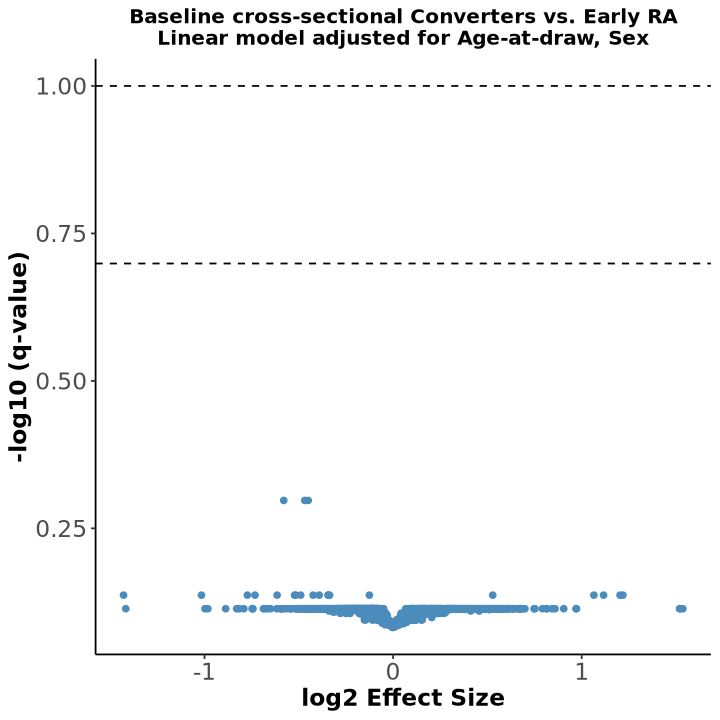

In [49]:
options(repr.plot.width = 6, repr.plot.height = 6)


ggplot(riskConvERA, aes(x=Estimate,
                        y=-log10(qval), 
                        colour=ifelse(Estimate < 0 & qval <= 0.2, 
                                     'down', 
                                      ifelse(Estimate > 0 & qval <= 0.2, 
                                             'up', 
                                             'ns')),
                        label=ifelse(qval <= 0.2, 
                                     Assay, 
                                     ''))) + 
    geom_point() + 
    geom_text_repel(size = 5) + 
    scale_colour_manual(values = c('#4C8CBD',
                                   'black', 
                                   '#F59F00')) + # NEJM colours 
    geom_hline(yintercept = -log10(0.1), 
               linetype = 'dashed') + 
    geom_hline(yintercept = -log10(0.2), 
               linetype = 'dashed') + 
    labs(title='Baseline cross-sectional Converters vs. Early RA\nLinear model adjusted for Age-at-draw, Sex',
         x='log2 Effect Size', 
         y='-log10 (q-value)') + 
    theme_classic() + 
    theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
           legend.position = 'none',
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

#### Volcano: ERA vs NONC
Reference = non-converters/NONC <br>
Positive effect size = increased in early_RA

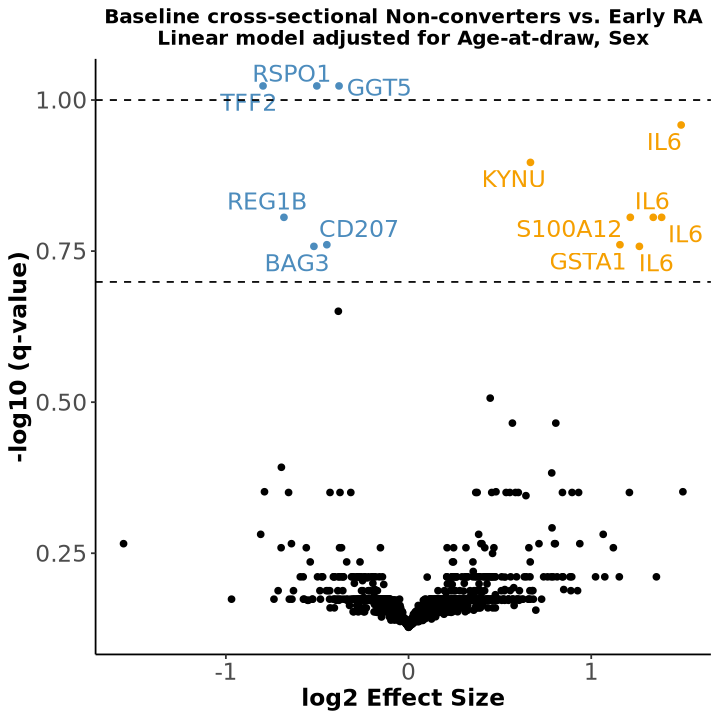

In [50]:
options(repr.plot.width = 6, repr.plot.height = 6)


ggplot(riskNoncERA, aes(x=Estimate,
                        y=-log10(qval), 
                        colour=ifelse(Estimate < 0 & qval <= 0.2, 
                                     'down', 
                                      ifelse(Estimate > 0 & qval <= 0.2, 
                                             'up', 
                                             'ns')),
                        label=ifelse(qval <= 0.2, 
                                     Assay, 
                                     ''))) + 
    geom_point() + 
    geom_text_repel(size = 5) + 
    scale_colour_manual(values = c('#4C8CBD',
                                   'black', 
                                   '#F59F00')) + # NEJM colours 
    geom_hline(yintercept = -log10(0.1), 
               linetype = 'dashed') + 
    geom_hline(yintercept = -log10(0.2), 
               linetype = 'dashed') + 
    labs(title='Baseline cross-sectional Non-converters vs. Early RA\nLinear model adjusted for Age-at-draw, Sex',
         x='log2 Effect Size', 
         y='-log10 (q-value)') + 
    theme_classic() + 
    theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
           legend.position = 'none',
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

#### Volcano: NONC vs CONV
Reference = converters/CONV <br>
Positive effect size = increased in non_converters

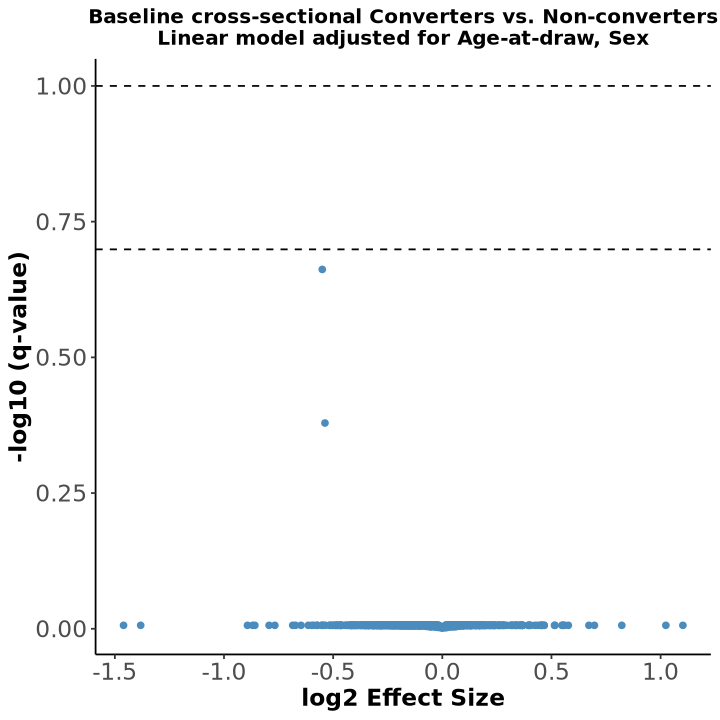

In [51]:
options(repr.plot.width = 6, repr.plot.height = 6)


ggplot(riskConvNC, aes(x=Estimate,
                        y=-log10(qval), 
                        colour=ifelse(Estimate < 0 & qval <= 0.2, 
                                     'down', 
                                      ifelse(Estimate > 0 & qval <= 0.2, 
                                             'up', 
                                             'ns')),
                        label=ifelse(qval <= 0.2, 
                                     Assay, 
                                     ''))) + 
    geom_point() + 
    geom_text_repel(size = 5) + 
    scale_colour_manual(values = c('#4C8CBD',
                                   'black', 
                                   '#F59F00')) + # NEJM colours 
    geom_hline(yintercept = -log10(0.1), 
               linetype = 'dashed') + 
    geom_hline(yintercept = -log10(0.2), 
               linetype = 'dashed') + 
    labs(title='Baseline cross-sectional Converters vs. Non-converters\nLinear model adjusted for Age-at-draw, Sex',
         x='log2 Effect Size', 
         y='-log10 (q-value)') + 
    theme_classic() + 
    theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
           legend.position = 'none',
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

#### Volcano: HC1 vs CONV
Reference = converters/CONV <br>
Positive effect size = increased in CONV (after inverting values)

In [52]:
proteins_to_label <- riskConvHC1 %>%
    slice_min(qval, n = 10) %>%
    distinct(OlinkID)

In [53]:
# add proteins to label
# add HC1|ARI q-value annotations
# invert effect size to match other volcano plots

riskConvHC1_annot <- riskConvHC1 %>%
    left_join(dap2, by = 'OlinkID') %>%
    mutate(Estimate = Estimate * (-1), 
           label = ifelse(OlinkID %in% proteins_to_label$OlinkID, 
                          Assay, 
                          ''), 
           aim1_annot = ifelse(OlinkID %in% proteins_to_label$OlinkID,
                               '1_label', 
                               ifelse(aim1_qval <= 0.1 & Estimate > 0, 
                                      '2_sig_up', 
                                      ifelse(aim1_qval <= 0.1 & Estimate < 0, 
                                             '3_sig_down', 
                                             'ns'))))


head(riskConvHC1_annot)
nrow(riskConvHC1_annot)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat,aim1_qval,label,aim1_annot
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,StatusALTRA_healthy,converter,1.2022240,3.192962e-06,OID20542,SCRN1,SCRN1_OID20542,Q12765,Q12765_OID20542,0.002461528,Down,8.039096e-06,SCRN1,1_label
2,StatusALTRA_healthy,converter,1.0101923,1.043822e-05,OID20427,IL1B,IL1B_OID20427,P01584,P01584_OID20427,0.004023533,Down,2.144259e-09,IL1B,1_label
3,StatusALTRA_healthy,converter,0.6074249,2.560453e-05,OID21404,PRDX6,PRDX6_OID21404,P30041,P30041_OID21404,0.006579707,Down,2.990074e-03,PRDX6,1_label
4,StatusALTRA_healthy,converter,1.8430646,4.373062e-05,OID20425,RAB37,RAB37_OID20425,Q96AX2,Q96AX2_OID20425,0.007225475,Down,2.276932e-04,RAB37,1_label
5,StatusALTRA_healthy,converter,0.6735081,4.686250e-05,OID20569,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,0.007225475,Down,2.776694e-06,CCL28,1_label
6,StatusALTRA_healthy,converter,0.4531251,1.155360e-04,OID21305,DPEP2,DPEP2_OID21305,Q9H4A9,Q9H4A9_OID21305,0.013120155,Down,5.395956e-05,DPEP2,1_label


[1] 1327

In [54]:
table(riskConvHC1_annot$aim1_annot)


   1_label   2_sig_up 3_sig_down         ns 
        10        239         23       1055 

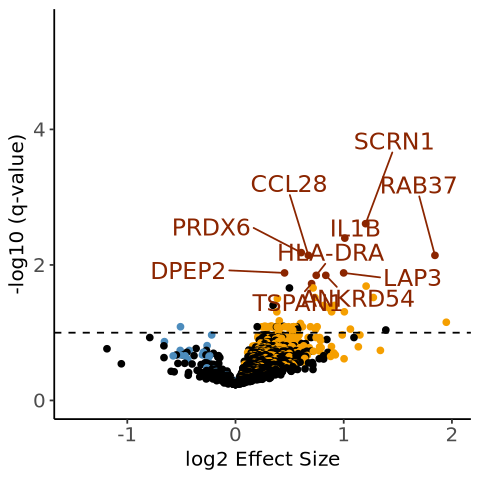

In [55]:
options(repr.plot.width = 4, repr.plot.height = 4)


p <- ggplot(riskConvHC1_annot, aes(x=Estimate,
                                   y=-log10(qval), 
                                   colour=aim1_annot, 
                                   label=label)) +
        geom_point() + 
        geom_text_repel(size = 5, 
                        min.segment.length = unit(0, 'lines'), 
                        max.overlaps = Inf, 
                        box.padding = 0.55) +
        scale_colour_manual(values = c('orangered4', 
                                       '#F59F00', 
                                       '#4C8CBD',
                                       'black')) + 
        geom_hline(yintercept = -log10(0.1), 
                   linetype = 'dashed') + 
        labs(#title='Baseline cross-sectional Converters vs. Healthy controls\nLinear model adjusted for Age-at-draw, Sex',
             x='log2 Effect Size', 
             y='-log10 (q-value)') + 
        xlim(-1.5, 2) + 
        ylim(0, 5.5) + 
        theme_classic() + 
        theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
               legend.position = 'none',
               axis.text.y = element_text(size = 12),
               axis.text.x = element_text(size = 12), 
               axis.title.y = element_text(size = 12), 
               axis.title.x = element_text(size = 12))

print(p)

In [56]:
ggsave(filename = 'Olink_Volcano_CONV_HC1.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 4, 
       height = 4, 
       units = 'in')

#### Volcano: HC1 vs NONC
Reference = non-converters/NONC <br>
Positive effect size = increased in NONC (after inverting values)

In [57]:
proteins_to_label2 <- riskNoncHC1 %>%
    slice_min(qval, n = 10, with_ties = F) %>%
    distinct(OlinkID)

In [58]:
# add proteins to label
# add HC1|ARI q-value annotations
# invert effect size to match other volcano plots

riskNoncHC1_annot <- riskNoncHC1 %>%
    left_join(dap2, by = 'OlinkID') %>%
    mutate(Estimate = Estimate * (-1), 
           label = ifelse(OlinkID %in% proteins_to_label2$OlinkID, 
                          Assay, 
                          ''), 
           aim1_annot = ifelse(OlinkID %in% proteins_to_label2$OlinkID,
                               '1_label', 
                               ifelse(aim1_qval <= 0.1 & Estimate > 0, 
                                      '2_sig_up', 
                                      ifelse(aim1_qval <= 0.1 & Estimate < 0, 
                                             '3_sig_down', 
                                             'ns'))))


head(riskNoncHC1_annot)
nrow(riskNoncHC1_annot)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,pcat,aim1_qval,label,aim1_annot
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,StatusALTRA_healthy,non_converter,1.0914223,5.131544e-09,OID20427,IL1B,IL1B_OID20427,P01584,P01584_OID20427,4.249371e-06,Down,2.144259e-09,IL1B,1_label
2,StatusALTRA_healthy,non_converter,0.7966106,5.886673e-07,OID20520,HLA-DRA,HLA-DRA_OID20520,P01903,P01903_OID20520,2.437342e-04,Down,8.039096e-06,HLA-DRA,1_label
3,StatusALTRA_healthy,non_converter,0.9524595,2.273094e-06,OID20542,SCRN1,SCRN1_OID20542,Q12765,Q12765_OID20542,6.274408e-04,Down,8.039096e-06,SCRN1,1_label
4,StatusALTRA_healthy,non_converter,0.5988980,4.555073e-06,OID20569,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,9.430006e-04,Down,2.776694e-06,CCL28,1_label
5,StatusALTRA_healthy,non_converter,1.2561232,1.972508e-05,OID20068,TIA1,TIA1_OID20068,P31483,P31483_OID20068,3.266822e-03,Down,5.395956e-05,TIA1,1_label
6,StatusALTRA_healthy,non_converter,0.6950789,3.683219e-05,OID21361,IQGAP2,IQGAP2_OID21361,Q13576,Q13576_OID21361,5.083384e-03,Down,5.395956e-05,IQGAP2,1_label


[1] 1327

In [59]:
table(riskNoncHC1_annot$aim1_annot)


   1_label   2_sig_up 3_sig_down         ns 
        10        239         23       1055 

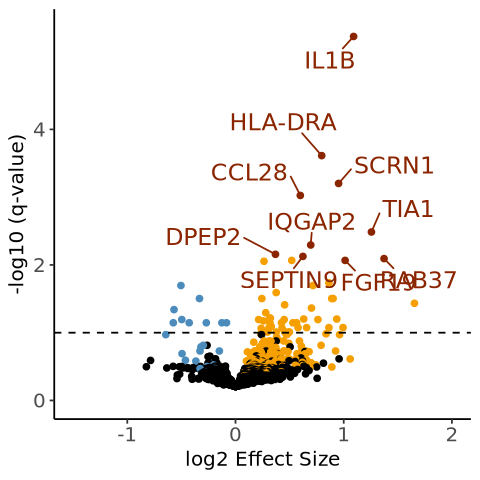

In [60]:
options(repr.plot.width = 4, repr.plot.height = 4)


p <- ggplot(riskNoncHC1_annot, aes(x=Estimate,
                                   y=-log10(qval), 
                                   colour=aim1_annot, 
                                   label=label)) +
        geom_point() + 
        geom_text_repel(size = 5, 
                        min.segment.length = unit(0, 'lines'), 
                        max.overlaps = Inf, 
                        box.padding = 0.55) +
        scale_colour_manual(values = c('orangered4', 
                                       '#F59F00', 
                                       '#4C8CBD',
                                       'black')) + 
        geom_hline(yintercept = 1.0, 
                   linetype = 'dashed') + # q=0.1 reference mark
        labs(#title='Baseline cross-sectional Non-converters vs. Healthy controls\nLinear model adjusted for Age-at-draw, Sex',
             x='log2 Effect Size', 
             y='-log10 (q-value)') + 
        xlim(-1.5, 2) + 
        ylim(0, 5.5) + 
        theme_classic() + 
        theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
               legend.position = 'none',
               axis.text.y = element_text(size = 12),
               axis.text.x = element_text(size = 12), 
               axis.title.y = element_text(size = 12), 
               axis.title.x = element_text(size = 12))

print(p)

In [61]:
ggsave(filename = 'Olink_Volcano_NONC_HC1.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 4, 
       height = 4, 
       units = 'in')

#### Correlation: CONV-ERA vs NONC-ERA

In [62]:
# function to join dataframes for correlation plots

joinDF <- function(df1, suf1, df2, suf2){

    in1 <- df1 %>%
        select(OlinkID, 
               Assay_OID, 
               Estimate, 
               qval)

    in2 <- df2 %>%
        select(OlinkID, 
               Assay_OID, 
               Estimate,
               qval)

    out <- in1 %>%
        left_join(in2, by = c('OlinkID', 'Assay_OID'), 
                  suffix = c(paste(suf1), paste(suf2)))

}

In [63]:
era_corr <- joinDF(riskConvERA, '_convERA', riskNoncERA, '_ncERA') %>%
    mutate(sig_annot = ifelse(qval_convERA <= 0.1 | qval_ncERA <= 0.1,
                              'L1_sig',
                              ifelse(qval_convERA > 0.1 & qval_convERA <= 0.2 | qval_ncERA > 0.1 & qval_ncERA <= 0.2,
                                     'L2_sig', 
                                     'NS')))


head(era_corr)
nrow(era_corr)

,OlinkID,Assay_OID,Estimate_convERA,qval_convERA,Estimate_ncERA,qval_ncERA,sig_annot
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,OID21484,L1CAM_OID21484,-0.4501981,0.5042267,-0.18369403,0.6457594,NS
2,OID21008,CDH3_OID21008,-0.5799277,0.5042267,-0.03015783,0.7226012,NS
3,OID21305,DPEP2_OID21305,-0.4682886,0.5042267,-0.38438300,0.2236404,NS
4,OID20529,FCRL6_OID20529,-1.0162810,0.7297195,-0.69762047,0.5506858,NS
5,OID20619,IDS_OID20619,-0.1258405,0.7297195,-0.04913135,0.6699381,NS
6,OID20667,CDSN_OID20667,-0.5224619,0.7297195,0.01499715,0.7294600,NS


[1] 1316

In [64]:
table(era_corr$sig_annot)


L1_sig L2_sig     NS 
     3     10   1303 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


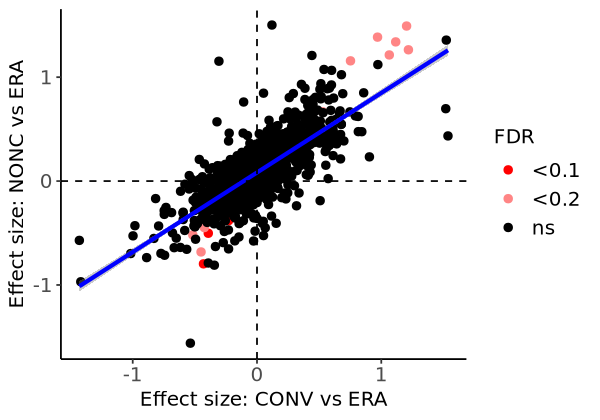

In [65]:
options(repr.plot.width = 5, repr.plot.height = 3.5)

p <- ggplot(era_corr, aes(x=Estimate_convERA, 
                     y=Estimate_ncERA, 
                     colour=sig_annot)) + 
    geom_point(size = 2) + 
    geom_smooth(method = 'lm', 
                colour = 'blue', 
                fill = 'grey50',
                size = 1.2) + 
    geom_hline(yintercept = 0, 
               linetype = 'dashed') +
    geom_vline(xintercept = 0, 
               linetype = 'dashed') + 
    scale_colour_manual(breaks = c('L1_sig', 
                                   'L2_sig', 
                                   'NS'),
                        labels = c('<0.1', 
                                   '<0.2', 
                                   'ns'), 
                        values = c('#FF0000', 
                                   '#FF8585', 
                                   'black'), 
                        name = 'FDR') +
    labs(x='Effect size: CONV vs ERA', 
         y='Effect size: NONC vs ERA') + 
    theme_classic() + 
    theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
           #legend.position = 'none',
           legend.text = element_text(size = 12),
           legend.title = element_text(size=12),
           axis.text.y = element_text(size = 12),
           axis.text.x = element_text(size = 12), 
           axis.title.y = element_text(size = 12), 
           axis.title.x = element_text(size = 12))

plot(p)

In [66]:
ggsave(filename = 'Olink_ERA_CONV_NONC_Corr.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 4, 
       height = 3, 
       units = 'in')

`geom_smooth()` using formula = 'y ~ x'


In [67]:
# differentials

era_corr %>%
    mutate(diff = abs(Estimate_convERA - Estimate_ncERA)) %>%
    slice_max(diff, n = 10)

OlinkID,Assay_OID,Estimate_convERA,qval_convERA,Estimate_ncERA,qval_ncERA,sig_annot,diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
OID21047,OXT_OID21047,-0.30635668,0.7785696,1.1537124,0.6152577,NS,1.4600691
OID21030,CCL19_OID21030,0.12018553,0.8046520,1.5018026,0.4448928,NS,1.3816170
OID21485,FOLR3_OID21485,1.53663536,0.7694817,0.4345881,0.6925333,NS,1.1020472
OID21263,GCG_OID21263,-0.53617888,0.7694817,-1.5601721,0.5422299,NS,1.0239932
OID21327,IL12A_IL12B_OID21327,-0.32202437,0.7694817,0.5703847,0.6699381,NS,0.8924091
OID20187,LEP_OID20187,-0.10739572,0.8039151,0.7609398,0.6152577,NS,0.8683355
OID21211,RUVBL1_OID21211,-1.42942869,0.7297195,-0.5708194,0.6699381,NS,0.8586093
OID20775,PNLIPRP2_OID20775,1.51881218,0.7694817,0.6966458,0.6985218,NS,0.8221663
OID20965,LAIR2_OID20965,0.05263884,0.8145699,0.8460182,0.6152577,NS,0.7933794


In [68]:
cor.test(x = era_corr$Estimate_convERA, 
         y = era_corr$Estimate_ncERA, 
         method = 'spearman')


	Spearman's rank correlation rho

data:  era_corr$Estimate_convERA and era_corr$Estimate_ncERA
S = 92361508, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7568497 


#### Correlation: CONV-HC1 vs NONC-HC1

In [69]:
hc1_corr <- joinDF(riskConvHC1, '_convHC1', riskNoncHC1, '_ncHC1')

head(hc1_corr)
nrow(hc1_corr)

,OlinkID,Assay_OID,Estimate_convHC1,qval_convHC1,Estimate_ncHC1,qval_ncHC1
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,OID20542,SCRN1_OID20542,-1.2022240,0.002461528,-0.9524595,6.274408e-04
2,OID20427,IL1B_OID20427,-1.0101923,0.004023533,-1.0914223,4.249371e-06
3,OID21404,PRDX6_OID21404,-0.6074249,0.006579707,-0.3011761,9.170182e-02
4,OID20425,RAB37_OID20425,-1.8430646,0.007225475,-1.3726521,8.063762e-03
5,OID20569,CCL28_OID20569,-0.6735081,0.007225475,-0.5988980,9.430006e-04
6,OID21305,DPEP2_OID21305,-0.4531251,0.013120155,-0.3692196,6.971461e-03


[1] 1327

In [70]:
# annotate HC1|ARI significant DAPs

hc1_corr2 <- hc1_corr %>%
    left_join(dap2, by = 'OlinkID') %>%
    mutate(aim1_annot = ifelse(aim1_qval <= 0.1, 
                               '1_sig', 
                               '2_ns'))

head(hc1_corr2)
nrow(hc1_corr2)

,OlinkID,Assay_OID,Estimate_convHC1,qval_convHC1,Estimate_ncHC1,qval_ncHC1,aim1_qval,aim1_annot
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,OID20542,SCRN1_OID20542,-1.2022240,0.002461528,-0.9524595,6.274408e-04,8.039096e-06,1_sig
2,OID20427,IL1B_OID20427,-1.0101923,0.004023533,-1.0914223,4.249371e-06,2.144259e-09,1_sig
3,OID21404,PRDX6_OID21404,-0.6074249,0.006579707,-0.3011761,9.170182e-02,2.990074e-03,1_sig
4,OID20425,RAB37_OID20425,-1.8430646,0.007225475,-1.3726521,8.063762e-03,2.276932e-04,1_sig
5,OID20569,CCL28_OID20569,-0.6735081,0.007225475,-0.5988980,9.430006e-04,2.776694e-06,1_sig
6,OID21305,DPEP2_OID21305,-0.4531251,0.013120155,-0.3692196,6.971461e-03,5.395956e-05,1_sig


[1] 1327

In [71]:
table(hc1_corr2$aim1_annot)


1_sig  2_ns 
  272  1055 

In [72]:
# invert effect sizes so they match original HC1|ARI analysis

hc1_corr2_inverted = hc1_corr2 %>%
    mutate(Estimate_convHC1 = Estimate_convHC1 * (-1), 
           Estimate_ncHC1 = Estimate_ncHC1 * (-1))

head(hc1_corr2_inverted)
nrow(hc1_corr2_inverted)

,OlinkID,Assay_OID,Estimate_convHC1,qval_convHC1,Estimate_ncHC1,qval_ncHC1,aim1_qval,aim1_annot
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,OID20542,SCRN1_OID20542,1.2022240,0.002461528,0.9524595,6.274408e-04,8.039096e-06,1_sig
2,OID20427,IL1B_OID20427,1.0101923,0.004023533,1.0914223,4.249371e-06,2.144259e-09,1_sig
3,OID21404,PRDX6_OID21404,0.6074249,0.006579707,0.3011761,9.170182e-02,2.990074e-03,1_sig
4,OID20425,RAB37_OID20425,1.8430646,0.007225475,1.3726521,8.063762e-03,2.276932e-04,1_sig
5,OID20569,CCL28_OID20569,0.6735081,0.007225475,0.5988980,9.430006e-04,2.776694e-06,1_sig
6,OID21305,DPEP2_OID21305,0.4531251,0.013120155,0.3692196,6.971461e-03,5.395956e-05,1_sig


[1] 1327

`geom_smooth()` using formula = 'y ~ x'


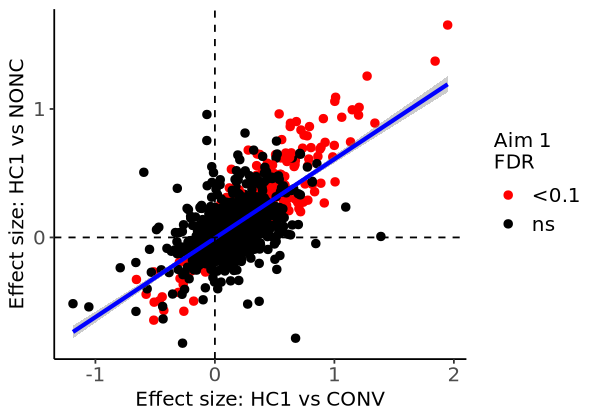

In [73]:
options(repr.plot.width = 5, repr.plot.height = 3.5)

p <- ggplot(hc1_corr2_inverted, aes(x=Estimate_convHC1, 
                               y=Estimate_ncHC1, 
                               colour=aim1_annot)) + 
    geom_point(size = 2) + 
    geom_smooth(method = 'lm', 
                colour = 'blue', 
                fill = 'grey50',
                size = 1.2) + 
    geom_hline(yintercept = 0, 
               linetype = 'dashed') +
    geom_vline(xintercept = 0, 
               linetype = 'dashed') + 
    scale_colour_manual(breaks = c('1_sig', 
                                   '2_ns'),
                        labels = c('<0.1',
                                   'ns'), 
                        values = c('#FF0000',
                                   'black'), 
                        name = 'Aim 1\nFDR') +
    labs(x='Effect size: HC1 vs CONV', 
         y='Effect size: HC1 vs NONC') + 
    theme_classic() + 
    theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
           #legend.position = 'none',
           legend.text = element_text(size = 12),
           legend.title = element_text(size=12),
           axis.text.y = element_text(size = 12),
           axis.text.x = element_text(size = 12), 
           axis.title.y = element_text(size = 12), 
           axis.title.x = element_text(size = 12))

plot(p)

In [74]:
ggsave(filename = 'Olink_HC1_CONV_NONC_Corr.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 4, 
       height = 3, 
       units = 'in')

`geom_smooth()` using formula = 'y ~ x'


In [75]:
# differentials

hc1_corr2_inverted %>%
    mutate(diff = abs(Estimate_convHC1 - Estimate_ncHC1)) %>%
    slice_max(diff, n = 10)

OlinkID,Assay_OID,Estimate_convHC1,qval_convHC1,Estimate_ncHC1,qval_ncHC1,aim1_qval,aim1_annot,diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
OID21047,OXT_OID21047,0.67515536,0.27935473,-0.784913722,0.2566518,0.2814865,2_ns,1.4600691
OID21030,CCL19_OID21030,1.38898164,0.09122705,0.007364594,0.6198654,0.2172931,2_ns,1.3816170
OID21485,FOLR3_OID21485,-0.59488593,0.37174023,0.507161308,0.4509183,0.4087469,2_ns,1.1020472
OID21263,GCG_OID21263,-0.06680856,0.55979895,0.957184681,0.2432518,0.1613205,2_ns,1.0239932
OID21327,IL12A_IL12B_OID21327,0.84435533,0.12611932,-0.048053771,0.5915112,0.2348001,2_ns,0.8924091
OID20187,LEP_OID20187,0.37070700,0.34930336,-0.497628517,0.3155681,0.2844939,2_ns,0.8683355
OID21211,RUVBL1_OID21211,1.09492438,0.11792815,0.236315110,0.4953617,0.1744623,2_ns,0.8586093
OID20775,PNLIPRP2_OID20775,-0.06772953,0.56992314,0.754436812,0.4714161,0.3164373,2_ns,0.8221663
OID20965,LAIR2_OID20965,0.27422701,0.42363277,-0.519152362,0.3180504,0.2715997,2_ns,0.7933794


In [76]:
cor.test(x = hc1_corr2$Estimate_convHC1, 
         y = hc1_corr2$Estimate_ncHC1, 
         method = 'spearman')


	Spearman's rank correlation rho

data:  hc1_corr2$Estimate_convHC1 and hc1_corr2$Estimate_ncHC1
S = 147529528, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.6211933 


## Store results in HISE

In [77]:
study_space_uuid <- '223de760-9624-45bd-aefe-ca24c75b1800'

title <- paste('ALTRA Olink 4-way Results: HC1 | NONC | CONV | ERA', Sys.Date())

In [78]:
search_id <- ids::proquint(n_words = 3)
search_id

[1] "borah-zidip-rajir"

In [79]:
in_list <- list(a1_uuid, a2_uuid, dap_uuid, meta_uuid)

In [80]:
outFiles

[[1]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_4way_refCONV_lm_allVariables.csv"

[[2]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_CONV_ERA_refCONV_lm.csv"

[[3]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_CONV_NONC_refCONV_lm.csv"

[[4]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_CONV_HC1_refCONV_lm.csv"

[[5]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_4way_refNONC_lm_allVariables.csv"

[[6]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_NONC_ERA_refNONC_lm.csv"

[[7]]
[1] "/home/workspace/temp/output/2025-03-23_Baseline_NONC_HC1_refNONC_lm.csv"

In [81]:
uploadFiles(
    files = outFiles,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    destination = search_id,
    store = "project",
    doPrompt = FALSE
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "7b5da728-e6fb-4776-849a-f7d98ddec1e6"

$ProcessId
[1] "c49380ff-af32-4cda-bbc4-759cf9775ad6"

$WorkflowId
[1] "1783e1a6-a9db-4432-af70-fc61d0c777a9"

$FileIds
$FileIds[[1]]
[1] "d5efcb09-581f-45c4-bbb0-a0c0232f9845"

$FileIds[[2]]
[1] "68c459f6-18b1-427b-a3a7-ab94915eae8e"

$FileIds[[3]]
[1] "7f8e47ab-ebde-4ebe-b199-4fb6a3d8ea63"

$FileIds[[4]]
[1] "f644f615-41b8-4745-98f2-01f3f56b3a17"

$FileIds[[5]]
[1] "9d46e79d-7500-4d1e-8cb9-7a07451edf1d"

$FileIds[[6]]
[1] "9c22cb35-a6df-42a3-8dc9-4a8e99ae6087"

$FileIds[[7]]
[1] "8e52c1fa-4905-487e-9bc8-7e533c931373"

In [82]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] RColorBrewer_1.1-3 ggrepel_0.9.5      ggplot2_3.5.1      qvalue_2.34.0     
 [5] forcats_1.0.0      tibble_3.2.1       tidyr_1.3.1        dplyr_1.1.4       
 [9] furrr_0.3.1        future_1.34.0      purrr_1.0.2        hise_2.16.0       

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        gene